In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from alibi.explainers import CounterfactualRL, Counterfactual
from matplotlib import pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense
from tensorflow import keras

C:\Users\chalo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### prepare the dataset

In [2]:
data=load_iris()
df= pd.DataFrame(data.data,columns=data.feature_names)
columns=data.feature_names
df['target']=data.target
df.head()
y=data.target
x=data.data

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### standardize the features

In [3]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### create an autoencoder

Epoch 1/10


C:\Users\chalo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.0838 
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0688
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0568
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0448
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0347
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0251
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0157
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0082
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0002
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9936


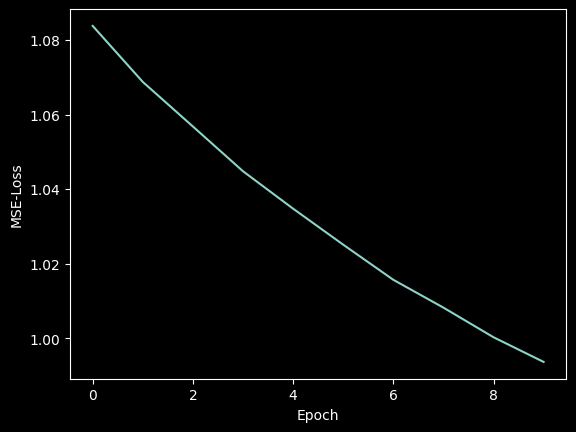

In [4]:
ENCODING_DIM = 7
BATCH_SIZE = 64
EPOCHS = 10

class AE(keras.Model):
    def __init__(self, encoder: keras.Model, decoder: keras.Model, **kwargs)-> None:
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def call(self, x: tf.Tensor, **kwargs):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

def make_ae():
    len_input_output = x_train_scaled.shape[-1]
    encoder = keras.Sequential()
    encoder.add(Dense(units=ENCODING_DIM*2, activation="relu", input_shape=(len_input_output, )))
    encoder.add(Dense(units=ENCODING_DIM, activation="relu"))
    decoder = keras.Sequential()
    decoder.add(Dense(units=ENCODING_DIM*2, activation="relu", input_shape=(ENCODING_DIM, )))
    decoder.add(Dense(units=len_input_output, activation="linear"))
    ae = AE(encoder=encoder, decoder=decoder)

    ae.compile(optimizer='adam', loss='mean_squared_error')
    history = ae.fit(x_train_scaled, x_train_scaled, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=True)
    loss = history.history['loss']
    plt.plot(loss)
    plt.xlabel('Epoch')
    plt.ylabel('MSE-Loss')
    plt.show()
    return ae

#Create the autoencoder
ae=make_ae()

### show the difference between any two instances

In [5]:
def compare_instances(x, cf):
    x = x.astype('float64')
    cf = cf.astype('float64')
    for f, v1, v2 in zip(features, x[0], cf[0]):
        print(f'{f:<25} instance: {round(v1, 3):^10} counter factual: {round(v2, 3):^10} difference: {round(v1- v2, 7):^5}')

### create and train the random forest classifier

In [6]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### generate a prediction and reshape an instance to the required format for the model

In [7]:
predict_fn = lambda x: model.predict_proba(x.reshape(x.shape[0],-1))
pred=predict_fn(x_test_scaled)[0:5]
print(pred)

def reshape(x):
    return x.reshape(x.shape[0],-1)

[[0.   0.99 0.01]
 [1.   0.   0.  ]
 [0.   0.04 0.96]
 [0.   0.99 0.01]
 [0.   0.89 0.11]]


In [8]:
cfrl_explainer = CounterfactualRL(
    predictor=predict_fn, # The model to explain
    encoder=ae.encoder, # The encoder
    decoder=ae.decoder, # The decoder
    latent_dim=7, # The dimension of the autoencoder latent space
    coeff_sparsity=0.5, # The coefficient of sparsity
    coeff_consistency=0.5, # The coefficient of consistency
    train_steps=10, # The number of training steps
    # Change batch_size to a smaller value to avoid empty batches during fit
    # Using a smaller batch size for the explainer, preferably a factor of the training data size
    batch_size=10, # Changed from 24
)

# Remove the reshape function call:
cfrl_explainer.fit(X=x_train_scaled) # Pass the data directly

100%|██████████| 10/10 [00:00<00:00, 27.89it/s]


CounterfactualRL(meta={
  'name': 'CounterfactualRL',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {
              'act_noise': 0.1,
              'act_low': -1.0,
              'act_high': 1.0,
              'replay_buffer_size': 1000,
              'batch_size': 10,
              'num_workers': 4,
              'shuffle': True,
              'exploration_steps': 100,
              'update_every': 1,
              'update_after': 10,
              'train_steps': 10,
              'backend': 'tensorflow',
              'encoder_preprocessor': 'identity_function',
              'decoder_inv_preprocessor': 'identity_function',
              'reward_func': 'get_classification_reward',
              'postprocessing_funcs': [],
              'conditional_func': 'generate_empty_condition',
              'callbacks': [],
              'actor': "<class 'alibi.models.tensorflow.actor_critic.Actor'>",
              'critic': "<class 'alibi.models.tensorflow.actor_critic.Criti

### explain an instance

In [9]:
x=x_test_scaled[0].reshape(1,-1)
result_cfrl = cfrl_explainer.explain(X=x, Y_t=np.array([1]))
print("Instance class prediction:", data.target_names[model.predict(x)])

countFactPred=model.predict(result_cfrl.data['cf']['X'])[0].argmax()
print("Counterfactual class prediction:", data.target_names[countFactPred])

x=scaler.inverse_transform(x)
counterFact=scaler.inverse_transform(result_cfrl.data['cf']['X'])
features=columns
compare_instances(x, counterFact)

100%|██████████| 1/1 [00:00<00:00, 26.51it/s]

Instance class prediction: ['versicolor']
Counterfactual class prediction: setosa
sepal length (cm)         instance:    6.1     counter factual:   5.802    difference: 0.2979198
sepal width (cm)          instance:    2.8     counter factual:   2.852    difference: -0.0524029
petal length (cm)         instance:    4.7     counter factual:   2.875    difference: 1.8253674
petal width (cm)          instance:    1.2     counter factual:   1.128    difference: 0.0722545
